In [1]:
import numpy as np
import pandas as pd
import copy

import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

from pathlib import Path
import glob

%matplotlib inline

In [2]:
import os

In [5]:
"""
Auto-reload external *.py modules on change before
each cell runs, no kernel restart needed.
"""
%load_ext autoreload
%autoreload 2

In [6]:
"""
Fijar semilla AL PRINCIPIO del notebook para garantizar reproducibilidad de resultados.
Esto asegura que cada ejecución del notebook produzca exactamente los mismos valores:
- Inicialización de pesos de la red neuronal
- División aleatoria de datos (validation_split)
- Mezcla de lotes (shuffle) durante el entrenamiento
- Operaciones de dropout (si se utilizan)
- Cualquier otra fuente de aleatoriedad en TensorFlow, NumPy y Python
"""

from scripts.set_seed import set_seed
set_seed(42)  # Fijada globalmente para todo el notebook

In [7]:
import sys
sys.path.append('scripts/')

In [8]:
from set_seed import main as test_set_seed
test_set_seed()

Ejecutando pruebas...
✓ Prueba de reproducibilidad exitosa!
✓ Prueba de seeds diferentes exitosa!
✓ Prueba de secuencia reproducible exitosa!
✓ Prueba de reproducibilidad de TensorFlow exitosa!

🎉 Todas las pruebas pasaron exitosamente!


/home/xopi/.pyenv/versions/3.13.2/envs/MEGAsync__IT_xopi_UNIR_MasterAI__04_TFM__CODE__digitial-twins-PVDAQ/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
from scripts.process_plant_export_metrics import *
from scripts.utils import *
from scripts.proccess_previous_to_model import *

# Load dataset

In [10]:
# Path to the dataset directory
dataset_path = "dataset/"

# Find all CSV files that end with "training.csv"
file_pattern = os.path.join(dataset_path, "*training.csv")
csv_files = glob.glob(file_pattern)

# List to store dataframes
dfs = []

# Read each CSV file and append to list
for file in sorted(csv_files):
    df = pd.read_csv(file)
    
    # print(df.info())
    if len(df) > 0:
        dfs.append(df)
        # print(f"CSV {file} added to dfs. Rows: {df.shape[0]:5d}")
    else:
        print(f"CSV {file} has 0 rows")

df = pd.concat(dfs, ignore_index=True)
df.shape

CSV dataset/pvdt_9068_2022_08_training.csv has 0 rows


(297643, 10)

# Prepocesado

In [11]:
from scripts.process_plant_export_metrics import process_plant_export_metrics

df = process_plant_export_metrics(df)

In [12]:
# Check NaN
df.isna().sum()

timestamp                     0
plant_ac_power_kw             0
inverter_1_ac_power_kw        0
inverter_2_ac_power_kw        0
poa_irradiance_wm2            0
ambient_temperature_c         0
module_temperature_c          0
hour                          0
dayofyear                     0
month                         0
total_inverter_ac_power_kw    0
plant_export_power_kw         0
meter_vs_inverter_diff_kw     0
meter_vs_inverter_diff_pct    0
dtype: int64

## Load PCA and scaler

In [13]:
from scripts.get_data_AWS import load_model
scaler = load_model('models/scaler_after_clean.pkl')
model_pca = load_model('models/pca_after_clean_norm.pkl')

Modelo cargado exitosamente
Tipo de modelo: <class 'sklearn.preprocessing._data.StandardScaler'>
Features esperadas: ['ambient_temperature_c' 'doy_cos' 'doy_sin' 'hour_cos' 'hour_sin'
 'module_temperature_c' 'poa_irradiance_wm2']
Modelo cargado exitosamente
Tipo de modelo: <class 'sklearn.decomposition._pca.PCA'>
Features esperadas: ['ambient_temperature_c' 'doy_cos' 'doy_sin' 'hour_cos' 'hour_sin'
 'module_temperature_c' 'poa_irradiance_wm2']


## Get `features`

In [14]:
TARGET = 'total_inverter_ac_power_kw'

features = model_pca.feature_names_in_

# Get `features` for apply_scaler()
if 'features' not in dir():
    df_previous_to_model, train_df, test_df = proccess_previous_to_model(df)
    features = sorted(set(train_df.columns) - set([TARGET]))
features

array(['ambient_temperature_c', 'doy_cos', 'doy_sin', 'hour_cos',
       'hour_sin', 'module_temperature_c', 'poa_irradiance_wm2'],
      dtype=object)

# Apply scaler & PCA

In [15]:
# Preprocess
df_previous_to_model = proccess_previous_to_model_fit(df)
df_previous_to_model.isna().sum()

timestamp                     0
plant_ac_power_kw             0
inverter_1_ac_power_kw        0
inverter_2_ac_power_kw        0
poa_irradiance_wm2            0
ambient_temperature_c         0
module_temperature_c          0
hour                          0
dayofyear                     0
month                         0
total_inverter_ac_power_kw    0
plant_export_power_kw         0
meter_vs_inverter_diff_kw     0
meter_vs_inverter_diff_pct    0
hour_sin                      0
hour_cos                      0
doy_sin                       0
doy_cos                       0
dtype: int64

In [16]:
from scripts.outliers import remove_outliers_high_threshold
from scripts.proccess_previous_to_model import get_train_test_dfs, apply_scaler

# Remove outliers
df_previous_to_model_clean = remove_outliers_high_threshold(df_previous_to_model, threshold=4) # same threshold as in 01.ipynb

# Z-scaler (all but "timestamp" and TARGET)
# scaler previously loaded
df_previous_to_model_clean_norm, scaler = apply_scaler(df_previous_to_model_clean, scaler=scaler, columns_to_scale=features)

# Get train & test
train_df_clean_norm, test_df_clean_norm = get_train_test_dfs(df_previous_to_model_clean_norm)

X_train_clean_norm = train_df_clean_norm[features]
y_train_clean = train_df_clean_norm[TARGET]

X_test_clean_norm = test_df_clean_norm[features]
y_test_clean = test_df_clean_norm[TARGET]

Columnas excluidas (std ≤ 1e-10): ['plant_export_power_kw']
Evaluando outliers en 16 columnas variables
Eliminadas 2572 filas de 290322 (0.89%)
Filas restantes: 287750


# PolynomialFeatures

In [97]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import make_pipeline

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge

cv = 3 # 5-fold (common default); 10-fold (traditional choice); 3- or 4-fold (for large datasets)
degree_arr = [8,9]
ridge__alpha_arr = np.power(10.,[-1, 0, 1])

if False:
    # Best: 0.6347 with {'degree': 9, 'alpha': 0.1}
    degree_arr = [9,10] 
    ridge__alpha_arr = [.1]

In [98]:
%%time

from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

X, y = model_pca.transform(X_train_clean_norm), y_train_clean

if False:
    # GridSearchCV stores all models, my df has 290k rows --> huge memory needed
    
    # Pipeline    
    pipeline = Pipeline([
        ('polynomialfeatures', PolynomialFeatures()),
        ('ridge', Ridge())
    ])
    
    param_clf = [
        {
            'polynomialfeatures__degree': degree_arr,
            'ridge__alpha': ridge__alpha_arr,
        }
    ]
    
    clf = GridSearchCV(pipeline, param_clf, cv=cv, n_jobs=-1, verbose=1)

    print("\nEntrenando PolynomialFeatures...")
    clf.fit(X, y)

    print(f"Best score: {clf.best_score_*100:.02f}% with degree {clf.best_params_['polynomialfeatures__degree']}")
    aux = cross_val_score(clf, X, y)
    print("cross_validation: ", end='')
    for k in aux: print(f"{k*100:.02f}%", end='   ')
    print(f"\nclf.best_params_:")
    print("\n".join([f"\t{key:30s} {value}" for key,value in clf.best_params_.items()]))
    print(80*'-')
    
    model_polyfit = clf.best_estimator_

else:
    # Manual grid search – only one model at a time

    best_score = -np.inf
    best_params = None
    
    # Loop manually – only one model exists at a time
    for degree in degree_arr:
        for alpha in ridge__alpha_arr:
            pipe = make_pipeline(
                PolynomialFeatures(degree=degree),
                Ridge(alpha=alpha)
            )
            # cross_val_score returns scores; models are discarded after each fold
            scores = cross_val_score(pipe, X, y, cv=cv, scoring='r2',
                                     n_jobs=-1 if degree<9 else +1 # Avoid n_jobs=-1 to prevent multiple large matrices simultaneously
                                    )
            mean_score = scores.mean()
            
            if mean_score > best_score:
                best_score = mean_score
                best_params = {'degree': degree, 'alpha': alpha}
            
            print(f"degree={degree:2d}, alpha={alpha:4.1f}: {mean_score:.4f}")
    
    print(f"Best: {best_score:.4f} with {best_params}")

    # Train again the best model on full data
    model_polyfit = make_pipeline(
        PolynomialFeatures(degree=best_params['degree']),
        Ridge(alpha=best_params['alpha'])
    )
    model_polyfit.fit(X, y)

degree= 8, alpha=0.1: 0.7231
degree= 8, alpha=1.0: 0.7231
degree= 8, alpha=10.0: 0.7191


/home/xopi/.pyenv/versions/3.13.2/envs/MEGAsync__IT_xopi_UNIR_MasterAI__04_TFM__CODE__digitial-twins-PVDAQ/lib/python3.13/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.0834606382707695e-17.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/home/xopi/.pyenv/versions/3.13.2/envs/MEGAsync__IT_xopi_UNIR_MasterAI__04_TFM__CODE__digitial-twins-PVDAQ/lib/python3.13/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.9220681215445758e-17.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/home/xopi/.pyenv/versions/3.13.2/envs/MEGAsync__IT_xopi_UNIR_MasterAI__04_TFM__CODE__digitial-twins-PVDAQ/lib/python3.13/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 4.661663199401876e-17.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


degree= 9, alpha=0.1: 0.6347


/home/xopi/.pyenv/versions/3.13.2/envs/MEGAsync__IT_xopi_UNIR_MasterAI__04_TFM__CODE__digitial-twins-PVDAQ/lib/python3.13/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.0396869796562611e-16.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/home/xopi/.pyenv/versions/3.13.2/envs/MEGAsync__IT_xopi_UNIR_MasterAI__04_TFM__CODE__digitial-twins-PVDAQ/lib/python3.13/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.9306548019798656e-16.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


degree= 9, alpha=1.0: 0.6620
degree= 9, alpha=10.0: 0.6994
Best: 0.7231 with {'degree': 8, 'alpha': np.float64(1.0)}
CPU times: user 8min, sys: 5.66 s, total: 8min 5s
Wall time: 1min 30s


In [99]:
print("Generando predicciones...")
y_pred_clean = model_polyfit.predict(model_pca.transform(X_test_clean_norm))

# Evitamos predicciones negativas por seguridad física.
y_pred_clean = np.clip(y_pred_clean, 0, None)

Generando predicciones...


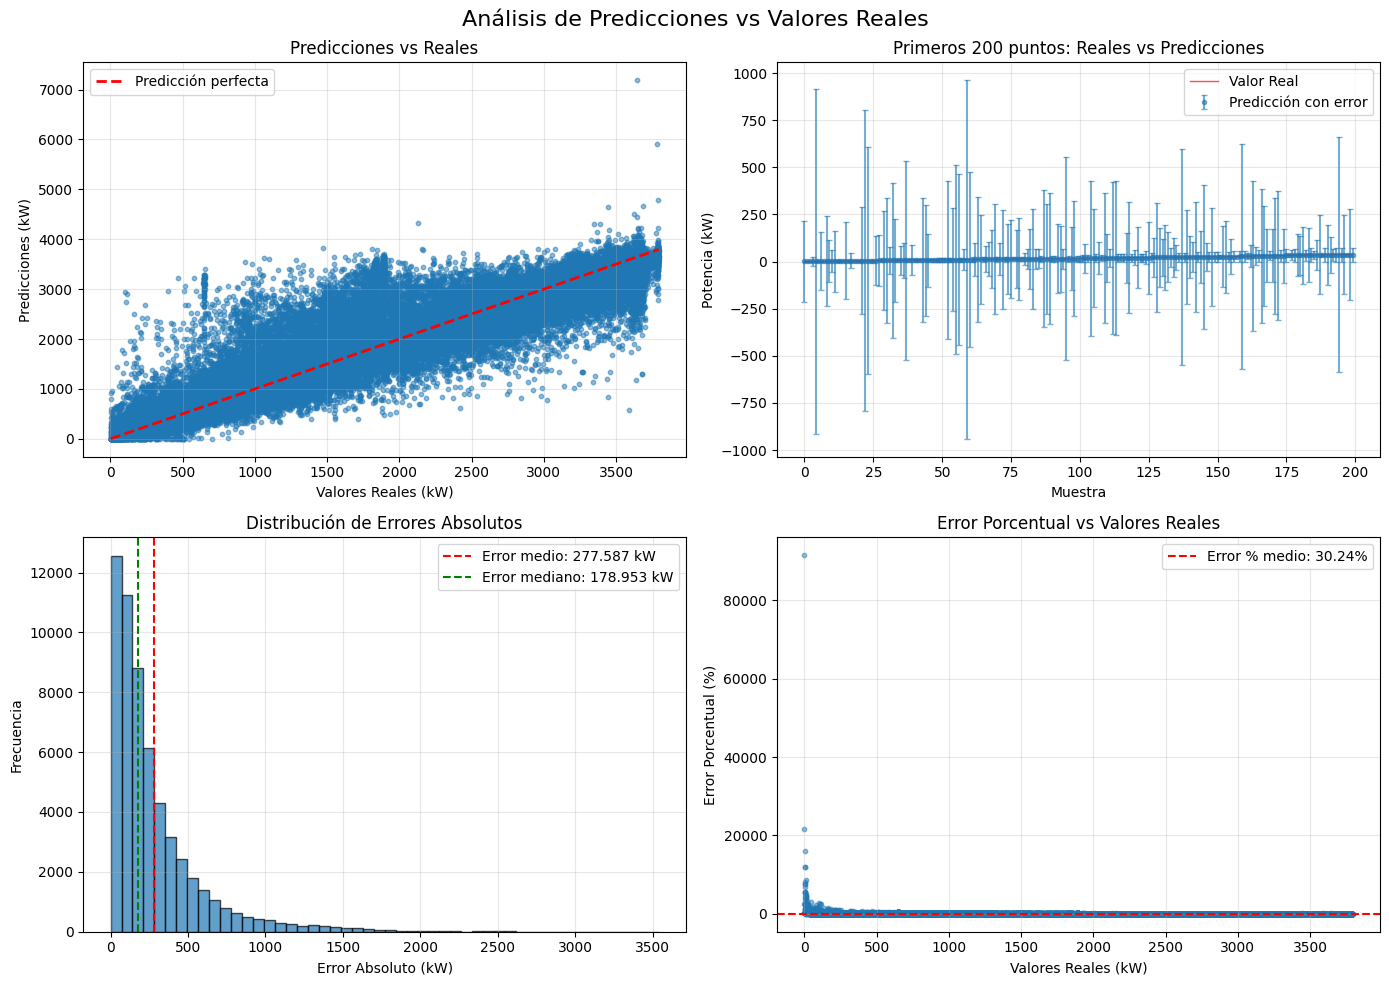


=== MÉTRICAS DE ERROR ===
MAE (Error Absoluto Medio): 277.5870 kW
RMSE: 414.9676 kW
MAPE (Error Porcentual Absoluto Medio): 30.24%
R²: 0.8792


In [100]:
plot_compare_test_pred(y_test_clean, y_pred_clean)

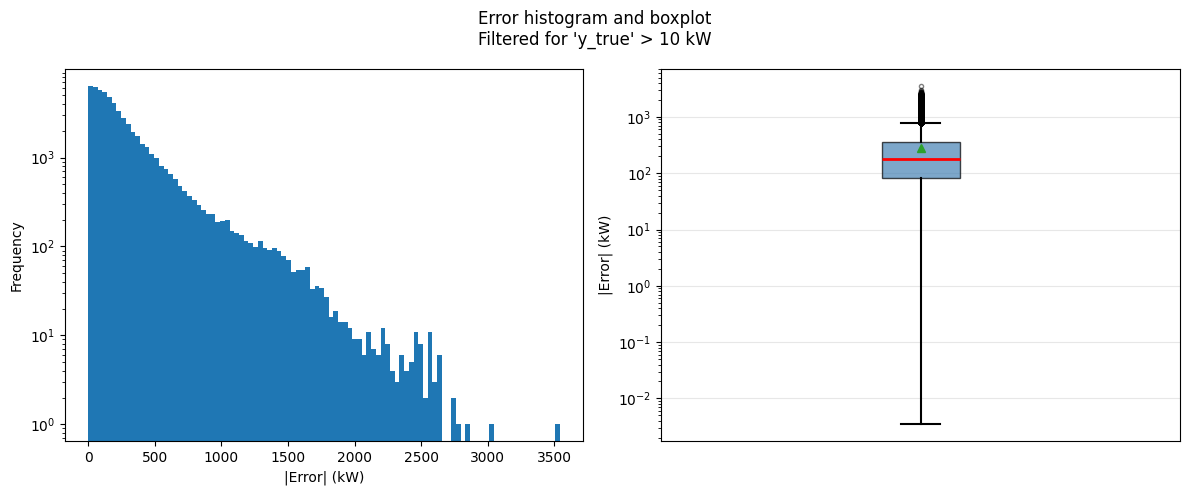

In [101]:
plot_hist_and_boxplot_error(y_test_clean, y_pred_clean)

## Check some conitnuous dates (e.g. whole April)

In [102]:
df_april_2024_curated_full = pd.read_csv("dataset/pvdt_9068_2024_04_curated_full.csv")

from scripts.proccess_previous_to_model import *
df_april_2024_to_fit_all_fields = proccess_previous_to_model_fit(df_april_2024_curated_full)

y_true = df_april_2024_to_fit_all_fields[TARGET]
df_april_2024_to_fit = get_df_for_model(df_april_2024_to_fit_all_fields)

In [103]:
# Z-scaler with previous scaler
df_april_2024_to_fit_norm, _ = apply_scaler(df_april_2024_to_fit, scaler=scaler, columns_to_scale=features)

In [104]:
# Filter cols
df_april_2024_to_fit_norm = get_df_for_model(df_april_2024_to_fit_norm)

# Reorder columns to match PCA model's expected order
df_april_2024_to_fit_norm = df_april_2024_to_fit_norm[model_pca.feature_names_in_]

# PCA
df_april_2024_to_fit_norm_pca = model_pca.transform(df_april_2024_to_fit_norm)

# ❗ Apply PolyFit-model
y_pred = model_polyfit.predict(df_april_2024_to_fit_norm_pca)

# PolyFit did not learn about POA = 0
if True:
    # Set 0.0 if low irradiance (model trained with no night data: training CSVs)
    # Here not needed cause X_test came from those training CSVs
    MIN_POA_WM2 = 50
    mask_low_POA = df_april_2024_to_fit_all_fields["poa_irradiance_wm2"] < MIN_POA_WM2
    y_pred[mask_low_POA] = 0.0

# Evitamos predicciones negativas por seguridad física.
y_pred = np.clip(y_pred, 0, None)

Estadísticas para predicciones con irradiance mayor a 50 W/m2
desde 2024-04-08 09:35:00
hasta 2024-04-30 23:55:00
	Error absoluto medio:   337.118 kW
	Error porcentual medio: 129565311.11%
	Desv. estándar error:   312.166 kW
	Percentil 95 error:     1019.956 kW


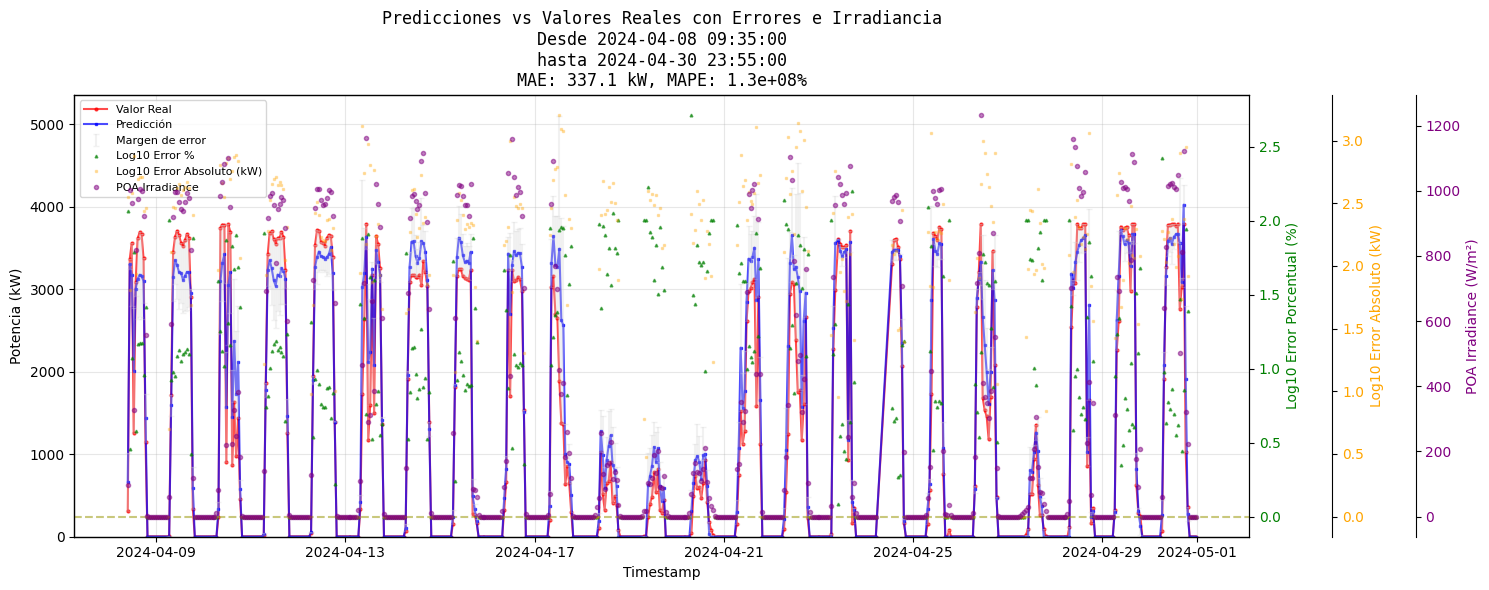

In [105]:
plot_df_pred_true(df_april_2024_to_fit_all_fields, y_true, y_pred);

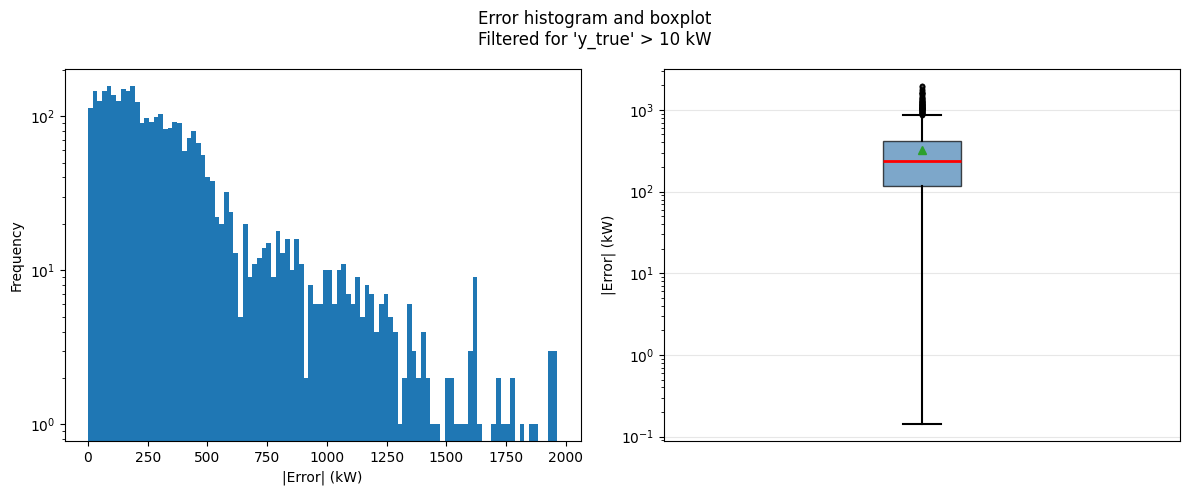

In [106]:
plot_hist_and_boxplot_error(y_true, y_pred)

## Store Model

In [108]:
import pickle

# Guardar el modelo
with open('models/polyfit_model.pkl', 'wb') as file:
    pickle.dump(model_polyfit, file)